# How are in-demand skills trending for Data Analysts?

Methology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

## Import Libraries and Data

In [ ]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Group the Skills by Month

Select only those job postings that are for Data Analysts and the job_country is the United States. Then extract the month from each job's posting date to see when the jobs are listed. Next, converts a column that lists skills into a usable list format. Finally, it arranges the data so that each skill from the list gets its own row. 

In [2]:
df_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country']=='United States')].copy()

df_US['job_posted_month_no'] = df_US['job_posted_date'].dt.month

df_US_explode = df_US.explode('job_skills')

## Pivot in Prep for Plotting

Create a pivot table from the df_US_explod, setting 'month' as index, job_skills as the columns, and fills missing entries with zero. 

In [3]:
df_US_pivot = df_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

In [4]:
df_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
2,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
3,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
4,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
5,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
6,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
7,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
8,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
9,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


### Sort columns by count and change month numbers to names

It adds a new row labeled ***Total*** that sums up counts across all months for each skills. Finally, it reorders the columns based on total counts, displaying them from highest to lowest, and shows the updated pivot table.

In [5]:
df_US_pivot.loc['Total'] = df_US_pivot.sum()

df_US_pivot = df_US_pivot.sort_values(by='Total',ascending=False,axis=1)

df_US_pivot.drop('Total',inplace=True)

## Plot the Monthly Skill Counts

Plot a line chart of the top 5 skills for data analysts, indexed by month. It selects the first five columns and plots them.

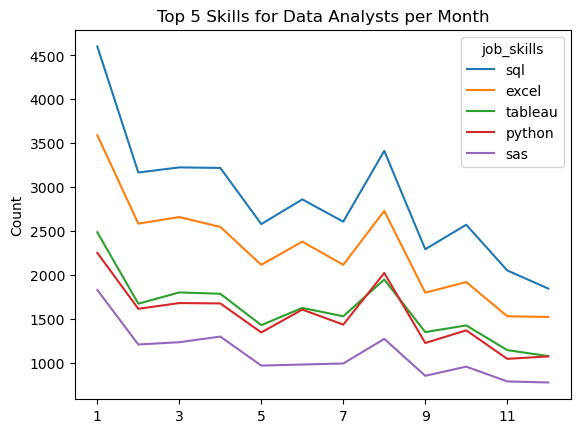

In [6]:
df_US_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

This is good but totals can be misleading without context. Percentages clarify relationships within the whole, giving a more accurate comparison.

## Calculate Percentage of Total Jobs

Calculates the total number of entries for each month in df_US by grouping the data by 'month' and counting the number of occurrences in each group, storing the results in df_US_total. This is needed to compute the percentages.

In [7]:
df_US_total = df_US.groupby('job_posted_month_no').size()

df_US_total

job_posted_month_no
1     8494
2     6124
3     6218
4     6049
5     4993
6     5683
7     5201
8     6634
9     4639
10    5271
11    4531
12    3979
dtype: int64

This code calculates the percentage of each skill's occurrence for each month by dividing the first 12 rows of the df_US_pivot DataFrame, which contains skill counts, by the monthly totals in df_US_totals and multiplying by 100. The new DataFrame, df_US_perc, shows skill distributions as percentages of total monthly job entries. 

In [8]:
# divide first 12 rows of df_US_pivot by df_US_totals

df_US_perc = df_US_pivot.iloc[:12].div(df_US_total/100, axis=0)

# change month number to month name

df_US_perc = df_US_perc.reset_index()
df_US_perc['job_posted_month'] = df_US_perc['job_posted_month_no'].apply(lambda x : pd.to_datetime (x, format='%m').strftime('%b'))
df_US_perc.set_index('job_posted_month', inplace=True)
df_US_perc.drop(columns='job_posted_month_no',inplace=True)
df_US_perc

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,54.167648,42.288674,29.291264,26.536379,21.568166,17.812574,15.740523,11.396280,11.443372,8.453026,...,0.011773,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,51.730895,42.243632,27.367734,26.420640,19.790986,17.064010,18.321359,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,51.881634,42.795111,29.012544,27.066581,19.909939,18.349952,16.950788,11.836603,10.759087,6.722419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016082
Apr,53.231939,42.139197,29.575136,27.756654,21.524219,17.159861,17.473963,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,51.692369,42.419387,28.680152,27.017825,19.467254,17.364310,17.224114,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020028,0.000000,0.000000,0.000000,0.000000
Jun,50.360725,41.914482,28.646841,28.312511,17.314799,17.895478,17.402780,12.686961,10.980116,7.284885,...,0.000000,0.000000,0.000000,0.017596,0.000000,0.000000,0.017596,0.017596,0.000000,0.000000
Jul,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,51.462165,41.166717,29.409105,30.524570,19.234248,19.158879,18.209225,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,49.471869,38.823022,29.165768,26.492779,18.452253,16.081052,17.676223,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Plot Monthly Skill Demand

Creates a line plot for the top five skills for data analysts, shown as percentages of the total job entries per month, using the first 5 columns of the df_US_perc DataFrame. Also the legend is moved outside of the plot for readibility.

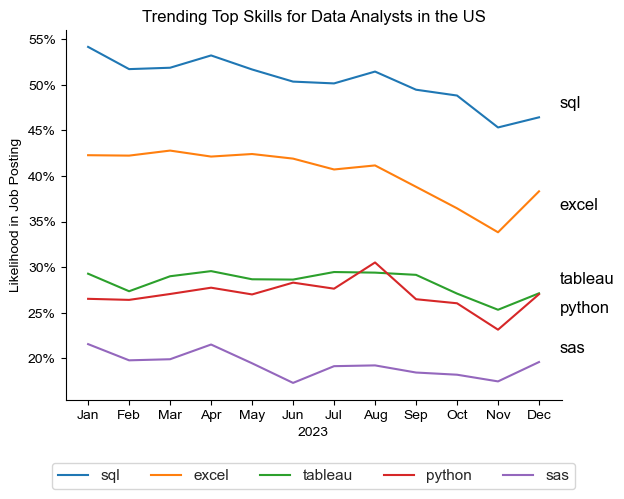

In [9]:
from matplotlib.ticker import PercentFormatter

df_plot = df_US_perc.iloc[:,:5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() #remove top and right spines

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

#bbox_to_anchor=(0.5, -0.15) means:
#Horizontally at 0.5 (middle of the axes width),
#Vertically at -0.15 (a bit below the axes).
#loc='upper center' says:The top center of the legend box will be placed at that coordinate.

plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(df_plot.shape[1]):
    y = df_plot.iloc[-1, i]
    plt.annotate(
        df_plot.columns[i],
        xy=(11, y),
        xytext=(11.5, y + 1.5 * (-1) ** i),  # offset alternately up/down
        arrowprops=dict(arrowstyle='->', lw=0.5),
        color='black',
        ha='left',
        va='center'
    )

plt.show()